# Q1 Research — NIH ChestX-ray14: Patient-Level Data Leakage (Full Run + CMPB Add-ons)

**Single-GPU, checkpoint-resumable full rerun.** Base patient-vs-random leakage study plus four CMPB add-ons:
1. Matched Grad-CAM / LIME (leaky vs rigorous)
2. ConvNeXt-Tiny architecture robustness
3. Leakage-severity (sibling dose-response)
4. Natural class-imbalance setting

Target pathology: **Effusion**. Run All top-to-bottom. If the kernel restarts, just re-run — finished folds/add-ons resume from `/kaggle/working/q1/checkpoints`.

In [1]:
import subprocess, sys
# Add-on 1 needs Grad-CAM + LIME. --no-deps keeps the preinstalled torch/torchvision untouched.
subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','ttach','grad-cam','lime'], check=True)
print('XAI deps ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.5 MB/s eta 0:00:00
XAI deps ready


In [2]:
import warnings, os, time
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # [SINGLE-GPU] use one GPU only to avoid the multi-GPU memory crash
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# --- [ADDED] Fast GPU sanity check -------------------------------------------
# Fails in ~1s with a clear message if the assigned GPU cannot run CUDA kernels,
# instead of crashing several minutes later during training. No modeling logic
# is changed; this only probes the device with a tiny conv+batchnorm+backward.
if DEVICE.type == 'cuda':
    try:
        _probe = nn.Sequential(nn.Conv2d(3, 8, 3), nn.BatchNorm2d(8)).to(DEVICE)
        _probe(torch.randn(2, 3, 32, 32, device=DEVICE)).sum().backward()
        torch.cuda.synchronize()
        _cap = torch.cuda.get_device_capability(0)
        print(f'GPU sanity check passed: {torch.cuda.get_device_name(0)} (sm_{_cap[0]}{_cap[1]}) | torch {torch.__version__}')
        del _probe; torch.cuda.empty_cache()
    except RuntimeError as _e:
        raise RuntimeError(
            "GPU cannot execute CUDA kernels: 'no kernel image is available for execution "
            "on the device' (cudaErrorNoKernelImageForDevice).\n"
            "This is a Kaggle accelerator/hardware<->torch mismatch, NOT a bug in this notebook.\n"
            "HOW TO FIX (right sidebar > Session options > Accelerator):\n"
            "  1) Switch accelerator to 'GPU P100' (single GPU) instead of 'GPU T4 x2' (or vice-versa).\n"
            "  2) Set Environment to 'Always use latest'.\n"
            "  3) Factory reset / restart the session, then Run All again.\n"
            f"GPU seen: {torch.cuda.get_device_name(0)} | torch {torch.__version__}\n"
            f"Original error: {_e}"
        ) from _e
else:
    print('WARNING: CUDA not available - training on CPU will be extremely slow.')

GPU sanity check passed: Tesla T4 (sm_75) | torch 2.10.0+cu128


In [4]:
IMG_SIZE=224; BATCH=32; EPOCHS=12; LR=1e-4; FOLDS=5; PATIENCE=3
SAMPLE=6000; TARGET='Effusion'; SEED=42
OUT=Path('/kaggle/working/q1'); OUT.mkdir(exist_ok=True)

In [5]:
# ====== [ADDED] CHECKPOINT / RESUME LAYER (safe re-run, no logic change) ======
# Saves each trained model + fold results to /kaggle/working so that if the
# kernel crashes, re-running re-loads finished steps instead of retraining.
import pickle
CKPT = OUT/'checkpoints'; CKPT.mkdir(parents=True, exist_ok=True)

def _sd(m):
    return (m.module if isinstance(m, nn.DataParallel) else m).state_dict()

def save_model_ckpt(m, tag):
    torch.save(_sd(m), CKPT/f'{tag}.pt')

def load_model_ckpt(model_fn, tag):
    p = CKPT/f'{tag}.pt'
    if not p.exists():
        return None
    m = model_fn()
    (m.module if isinstance(m, nn.DataParallel) else m).load_state_dict(torch.load(p, map_location=DEVICE))
    m.eval()
    return m

def save_pkl_ckpt(obj, tag):
    with open(CKPT/f'{tag}.pkl', 'wb') as fh:
        pickle.dump(obj, fh)

def load_pkl_ckpt(tag):
    p = CKPT/f'{tag}.pkl'
    if not p.exists():
        return None
    with open(p, 'rb') as fh:
        return pickle.load(fh)

def has_ckpt(tag):
    return (CKPT/f'{tag}.pkl').exists()

def strip_model(d):
    return {k: v for k, v in d.items() if k != 'model'}

print('Checkpoint layer ready ->', CKPT)

Checkpoint layer ready -> /kaggle/working/q1/checkpoints


In [6]:
# Auto-detect NIH dataset path
def find_nih():
    for p in ['/kaggle/input/datasets/nih-chest-xrays/data']:
        csvs = list(Path(p).rglob('Data_Entry_2017.csv'))
        if csvs: return Path(p), csvs[0]
    raise FileNotFoundError('Add nih-chest-xrays dataset to this notebook')

BASE, CSV = find_nih()
print(f'Root: {BASE}\nCSV:  {CSV}')
print('Indexing images...')
IDX = {f.name: str(f) for f in BASE.rglob('*.png')}
print(f'Indexed {len(IDX):,} images')

Root: /kaggle/input/datasets/nih-chest-xrays/data
CSV:  /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv
Indexing images...
Indexed 112,120 images


In [7]:
def load_data():
    df = pd.read_csv(CSV); df.columns = df.columns.str.strip()
    df['Label']      = df['Finding Labels'].apply(lambda x: 1 if TARGET in str(x) else 0)
    df['Patient_ID'] = df['Patient ID'].astype(str).str.strip()
    df['filepath']   = df['Image Index'].map(IDX)
    df = df.dropna(subset=['filepath']).reset_index(drop=True)
    pos=df[df.Label==1]; neg=df[df.Label==0]
    k=min(SAMPLE//2,len(pos),len(neg))
    df=pd.concat([pos.sample(k,random_state=SEED),neg.sample(k,random_state=SEED)])
    df=df.sample(frac=1,random_state=SEED).reset_index(drop=True)
    print(f'{len(df)} images | {df.Patient_ID.nunique()} patients')
    print(df.Label.value_counts()); return df

nih = load_data()

6000 images | 3919 patients
Label
1    3000
0    3000
Name: count, dtype: int64


In [8]:
MN=[0.485,0.456,0.406]; ST=[0.229,0.224,0.225]

BT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),
                T.ToTensor(),T.Normalize(MN,ST)])
AT = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),
                T.RandomHorizontalFlip(0.5),T.RandomAffine(10,translate=(0.05,0.05)),
                T.ColorJitter(brightness=0.15,contrast=0.15),
                T.ToTensor(),T.Normalize(MN,ST)])

# [SPEED FIX] NIH ChestX-ray14 are 1024x1024 PNGs. Re-decoding them from disk every
# epoch is the real bottleneck. We decode+resize each image ONCE and cache the small
# RGB in RAM, so every later epoch/model is near-instant. draft() accelerates JPEGs
# (harmless no-op for PNG). num_workers=0 keeps ONE shared cache in the main process
# (persists across ALL models) and removes any DataLoader worker-fork hang.
_IMG_CACHE = {}
def _load_img(path):
    im = _IMG_CACHE.get(path)
    if im is None:
        im = Image.open(path)
        try: im.draft('RGB', (IMG_SIZE*2, IMG_SIZE*2))
        except Exception: pass
        im = im.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        _IMG_CACHE[path] = im
    return im

class DS(Dataset):
    def __init__(self,df,aug=False): self.df=df.reset_index(drop=True); self.t=AT if aug else BT
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return self.t(_load_img(r.filepath)),int(r.Label),str(r.Patient_ID)

def dl(df,aug=False,sh=True):
    return DataLoader(DS(df,aug),batch_size=BATCH,shuffle=sh,num_workers=0,pin_memory=True)

print('Dataset class ready (fast decode + RAM cache, single-process loader)')

Dataset class ready (fast decode + RAM cache, single-process loader)


In [9]:
# def mkmodel():
#     m=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#     m.fc=nn.Linear(m.fc.in_features,2); return m.to(DEVICE)

def mkmodel():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        print(f'  Using {torch.cuda.device_count()} GPUs via DataParallel')
        m = nn.DataParallel(m)
    return m

def evl(model,loader):
    model.eval(); yt,yp,ypr=[],[],[]; fn=nn.CrossEntropyLoss(); tl=0
    with torch.no_grad():
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); lg=model(x)
            tl+=fn(lg,y).item()
            yt.extend(y.cpu().numpy()); yp.extend(lg.argmax(1).cpu().numpy())
            ypr.extend(torch.softmax(lg,1)[:,1].cpu().numpy())
    yt,yp,ypr=map(np.array,[yt,yp,ypr])
    auc=roc_auc_score(yt,ypr) if len(np.unique(yt))>1 else 0.5
    return tl/max(len(loader),1),auc,accuracy_score(yt,yp),f1_score(yt,yp,zero_division=0),yt,yp,ypr

print('Model + evaluator ready')

Model + evaluator ready


In [10]:
# Embedding Memorization Quotient (EMQ)
# EMQ = sibling_cosine_sim / inter_patient_cosine_sim
# EMQ > 1 => model relies on augmentation artifacts more than clinical features
def mq(model,df,n=120):
    model.eval(); buf={}; cos=nn.CosineSimilarity(dim=0)
    base = model.module if isinstance(model, nn.DataParallel) else model
    h = base.avgpool.register_forward_hook(lambda m,i,o: buf.update({'e':o.detach().squeeze()}))
    # h=model.avgpool.register_forward_hook(lambda m,i,o: buf.update({'e':o.detach().squeeze()}))
    sub=df.sample(min(n,len(df)),random_state=SEED).reset_index(drop=True)
    ce,ae,lb=[],[],[]
    for _,r in sub.iterrows():
        img=Image.open(r.filepath).convert('RGB')
        with torch.no_grad():
            model(BT(img).unsqueeze(0).to(DEVICE)); ce.append(buf['e'].view(-1).cpu())
            model(AT(img).unsqueeze(0).to(DEVICE)); ae.append(buf['e'].view(-1).cpu())
        lb.append(int(r.Label))
    h.remove()
    ce,ae,lb=torch.stack(ce),torch.stack(ae),np.array(lb)
    sib=np.mean([cos(ce[i],ae[i]).item() for i in range(len(ce))])
    intr=[]
    for c in [0,1]:
        ix=np.where(lb==c)[0][:12]
        for i in range(len(ix)):
            for j in range(i+1,len(ix)): intr.append(cos(ce[ix[i]],ce[ix[j]]).item())
    ip=np.mean(intr) if intr else 1.0
    return round(sib/ip,4),round(sib,4),round(ip,4)

print('MQ ready')

MQ ready


In [11]:
def train(tr,te,fold,name):
    print(f'  [F{fold}] {name}  tr={len(tr)} te={len(te)}', flush=True)
    trL=dl(tr,aug=True); teL=dl(te,aug=False,sh=False)
    m=mkmodel(); opt=torch.optim.Adam(m.parameters(),lr=LR,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,EPOCHS)
    fn=nn.CrossEntropyLoss(); best=0; bst=None; cnt=0
    for ep in range(EPOCHS):
        _ep_t=time.time()
        m.train()
        for x,y,_ in trL:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); fn(m(x),y).backward(); opt.step()
        sch.step()
        _,vauc,_,_,_,_,_=evl(m,teL)
        print(f'      {name} F{fold} epoch {ep+1}/{EPOCHS}  valAUC={vauc:.4f}  ({time.time()-_ep_t:.0f}s)', flush=True)
        if vauc>best: best=vauc; bst={k:v.clone() for k,v in m.state_dict().items()}; cnt=0
        else:
            cnt+=1
            if cnt>=PATIENCE: print(f'      {name} F{fold} early-stop at epoch {ep+1}', flush=True); break
    m.load_state_dict(bst)
    _,auc,acc,f1,yt,yp,ypr=evl(m,teL)
    q,s,ip=mq(m,te)
    print(f'    AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f} MQ={q:.4f}', flush=True)
    return dict(model=m,auc=auc,acc=acc,f1=f1,mq=q,sib=s,inter=ip,yt=yt,yp=yp,ypr=ypr)

print('train() ready (per-epoch heartbeat)')

train() ready (per-epoch heartbeat)


In [12]:
import time, gc
gkf = list(GroupKFold(FOLDS).split(nih, nih.Label, groups=nih.Patient_ID))
rkf = list(KFold(FOLDS, shuffle=True, random_state=SEED).split(nih))
PR, RR = [], []
mc_yt, mc_pat, mc_ran = [], [], []
fold_times = []

for f in range(FOLDS):
    print(f'\n{"="*55}\nFOLD {f+1}/{FOLDS}')
    if fold_times:
        avg = sum(fold_times)/len(fold_times)
        print(f'  ETA remaining folds: ~{avg*(FOLDS-f)/60:.0f} min')
    print('='*55)
    fold_start = time.time()

    # [RESUME] load a finished fold from checkpoint instead of retraining
    if has_ckpt(f'orig_fold{f+1}'):
        _c = load_pkl_ckpt(f'orig_fold{f+1}')
        rp = _c['PR']; rp['model'] = load_model_ckpt(mkmodel, f'orig_PR_model_fold{f+1}')
        PR.append(rp); RR.append(_c['RR'])
        mc_yt.extend(rp['yt']); mc_pat.extend(rp['yp']); mc_ran.extend(_c['RR']['yp'])
        print(f'  loaded fold {f+1} from checkpoint (skipped retraining)')
        continue

    ti, ei = gkf[f]
    trG = nih.iloc[ti].reset_index(drop=True); teG = nih.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique() < 2:
        print('  Skip: single-class test fold'); continue

    print('\n[A] PATIENT-SPLIT (Rigorous):')
    rp = train(trG, teG, f+1, 'Patient-Split'); PR.append(rp)

    ti2, ei2 = rkf[f]
    trR = nih.iloc[ti2].reset_index(drop=True); teR = nih.iloc[ei2].reset_index(drop=True)
    print('\n[B] RANDOM-SPLIT (Leaky):')
    rr = train(trR, teR, f+1, 'Random-Split')
    _, af, ac, f1f, _, ypf, yprf = evl(rr['model'], dl(teG, aug=False, sh=False))
    qf, sf, ipf = mq(rr['model'], teG)
    RR.append(dict(auc=af, acc=ac, f1=f1f, mq=qf, sib=sf, inter=ipf, yp=ypf, ypr=yprf))
    print(f'    [Fair@PatientTest] AUC={af:.4f} MQ={qf:.4f}')
    mc_yt.extend(rp['yt']); mc_pat.extend(rp['yp']); mc_ran.extend(ypf)

    # checkpoint this fold, then free the leaky model to save RAM/VRAM
    save_model_ckpt(rp['model'], f'orig_PR_model_fold{f+1}')
    save_pkl_ckpt({'PR': strip_model(rp), 'RR': RR[-1]}, f'orig_fold{f+1}')
    del rr['model'], rr; gc.collect(); torch.cuda.empty_cache()

    fold_times.append(time.time()-fold_start)
    print(f'  fold {f+1} done + checkpointed: {fold_times[-1]/60:.1f} min')

print('\nAll base folds complete.')


FOLD 1/5

[A] PATIENT-SPLIT (Rigorous):
  [F1] Patient-Split  tr=4800 te=1200
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


      Patient-Split F1 epoch 1/12  valAUC=0.8490  (219s)
      Patient-Split F1 epoch 2/12  valAUC=0.8533  (62s)
      Patient-Split F1 epoch 3/12  valAUC=0.8608  (60s)
      Patient-Split F1 epoch 4/12  valAUC=0.8587  (60s)
      Patient-Split F1 epoch 5/12  valAUC=0.8553  (60s)
      Patient-Split F1 epoch 6/12  valAUC=0.8556  (60s)
      Patient-Split F1 early-stop at epoch 6
    AUC=0.8608 ACC=0.7825 F1=0.7823 MQ=1.4776

[B] RANDOM-SPLIT (Leaky):
  [F1] Random-Split  tr=4800 te=1200
      Random-Split F1 epoch 1/12  valAUC=0.8273  (61s)
      Random-Split F1 epoch 2/12  valAUC=0.8448  (60s)
      Random-Split F1 epoch 3/12  valAUC=0.8569  (60s)
      Random-Split F1 epoch 4/12  valAUC=0.8524  (60s)
      Random-Split F1 epoch 5/12  valAUC=0.8604  (60s)
      Random-Split F1 epoch 6/12  valAUC=0.8509  (60s)
      Random-Split F1 epoch 7/12  valAUC=0.8484  (60s)
      Random-Split F1 epoch 8/12  valAUC=0.8488  (60s)
      Random-Split F1 early-stop at epoch 8
    AUC=0.8604 ACC=0.774

In [13]:
def ci(v): v=np.array(v); m=v.mean(); c=1.96*v.std(ddof=1)/np.sqrt(len(v)); return m,c

rows={}
for met in ['auc','acc','f1','mq']:
    pm,pc=ci([r[met] for r in PR]); rm,rc=ci([r[met] for r in RR])
    rows[met.upper()]={'Patient-Split':f'{pm:.4f}±{pc:.4f}','Random-Split':f'{rm:.4f}±{rc:.4f}','Delta':f'{rm-pm:+.4f}'}

df_res=pd.DataFrame(rows).T
print('\nFINAL Q1 RESULTS (Mean ± 95%CI)'); print('='*55); print(df_res.to_string())
df_res.to_csv(OUT/'results.csv')


FINAL Q1 RESULTS (Mean ± 95%CI)
     Patient-Split   Random-Split    Delta
AUC  0.8504±0.0140  0.9215±0.0142  +0.0711
ACC  0.7755±0.0093  0.8442±0.0139  +0.0687
F1   0.7713±0.0094  0.8451±0.0137  +0.0738
MQ   1.4867±0.0474  1.5424±0.1479  +0.0557


In [14]:
yt=np.array(mc_yt); ypp=np.array(mc_pat); yrr=np.array(mc_ran)
pc_=(ypp==yt); rc_=(yrr==yt)
tbl=[[int(np.sum(pc_&rc_)),int(np.sum(pc_&~rc_))],
     [int(np.sum(~pc_&rc_)),int(np.sum(~pc_&~rc_))]]
res=mcnemar(tbl,exact=False,correction=True)
print(f'McNemar chi2={res.statistic:.4f}  p={res.pvalue:.2e}')
print('SIGNIFICANT p<0.05' if res.pvalue<0.05 else 'Not significant')
with open(OUT/'mcnemar.txt','w') as f: f.write(f'chi2={res.statistic:.4f} p={res.pvalue:.2e}')

McNemar chi2=200.6188  p=1.53e-45
SIGNIFICANT p<0.05


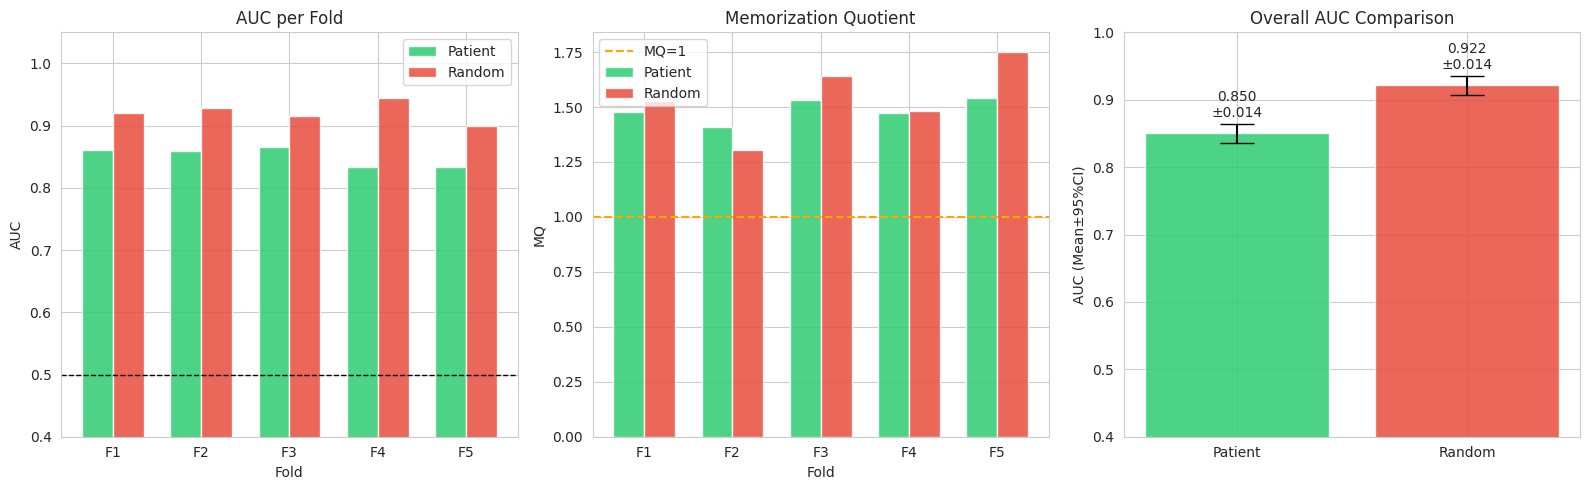

In [15]:
sns.set_style('whitegrid'); fig,axes=plt.subplots(1,3,figsize=(16,5))
n=len(PR); x=np.arange(n); w=0.35; lbl=[f'F{i+1}' for i in range(n)]

ax=axes[0]
ax.bar(x-w/2,[r['auc'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['auc'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(0.5,ls='--',c='k',lw=1); ax.set(xlabel='Fold',ylabel='AUC',title='AUC per Fold',ylim=[0.4,1.05],xticks=x,xticklabels=lbl); ax.legend()

ax=axes[1]
ax.bar(x-w/2,[r['mq'] for r in PR],w,label='Patient',color='#2ecc71',alpha=0.85)
ax.bar(x+w/2,[r['mq'] for r in RR],w,label='Random',color='#e74c3c',alpha=0.85)
ax.axhline(1.0,ls='--',c='orange',lw=1.5,label='MQ=1'); ax.set(xlabel='Fold',ylabel='MQ',title='Memorization Quotient',xticks=x,xticklabels=lbl); ax.legend()

ax=axes[2]
pm,pc_=ci([r['auc'] for r in PR]); rm,rc_=ci([r['auc'] for r in RR])
ax.bar(['Patient','Random'],[pm,rm],yerr=[pc_,rc_],capsize=12,color=['#2ecc71','#e74c3c'],alpha=0.85)
ax.set(ylabel='AUC (Mean±95%CI)',title='Overall AUC Comparison',ylim=[0.4,1.0])
for i,(m_,c_) in enumerate([(pm,pc_),(rm,rc_)]): ax.text(i,m_+c_+0.01,f'{m_:.3f}\n±{c_:.3f}',ha='center')

plt.tight_layout(); plt.savefig(OUT/'fig1_auc_mq.png',dpi=300,bbox_inches='tight'); plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

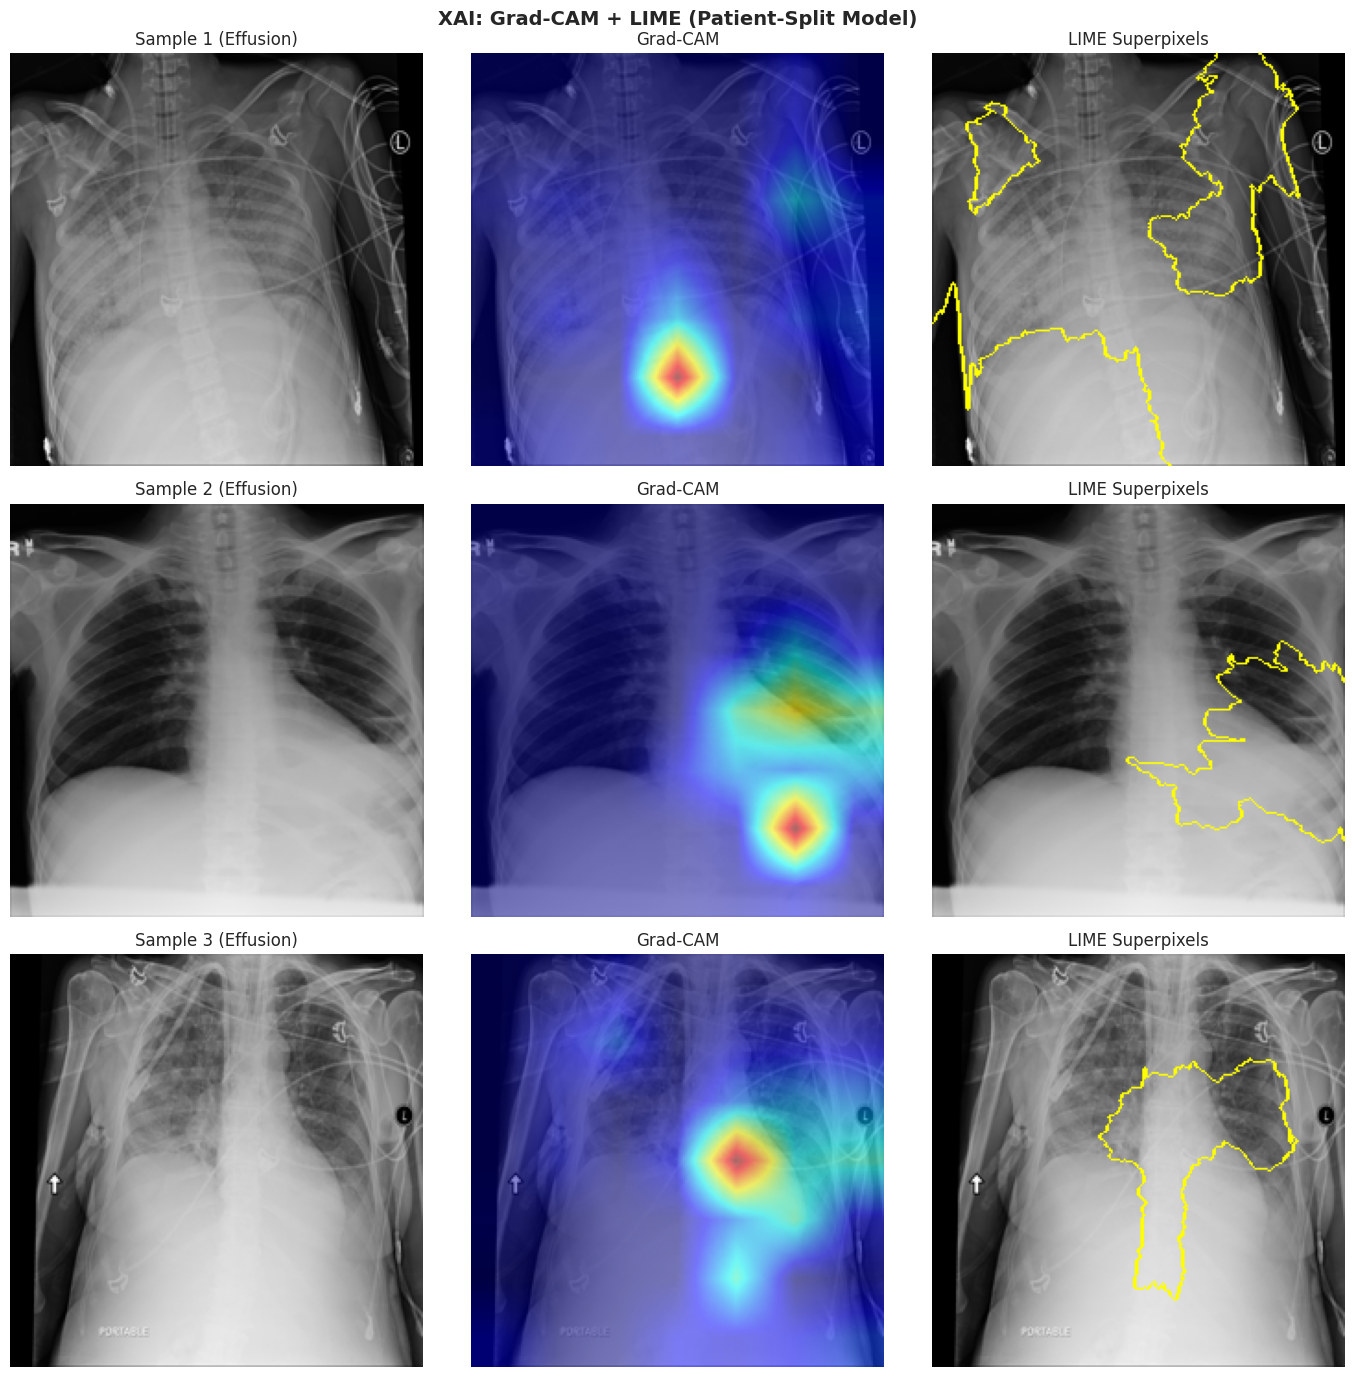

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

best_m=PR[-1]['model']; best_m.eval()
last_te=nih.iloc[gkf[-1][1]].reset_index(drop=True)
xai_df=last_te[last_te.Label==1].sample(3,random_state=42).reset_index(drop=True)

# cam=GradCAM(model=best_m,target_layers=[best_m.layer4[-1]])
base_m = best_m.module if isinstance(best_m, nn.DataParallel) else best_m
cam = GradCAM(model=best_m, target_layers=[base_m.layer4[-1]])
lime_e=lime_image.LimeImageExplainer()

MN_np=np.array([0.485,0.456,0.406]); ST_np=np.array([0.229,0.224,0.225])

def lime_pred(imgs):
    best_m.eval()
    norm=T.Normalize(MN_np.tolist(),ST_np.tolist())
    ts=torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
    with torch.no_grad(): return torch.softmax(best_m(ts),1).cpu().numpy()

fig,axes=plt.subplots(3,3,figsize=(14,14))
fig.suptitle('XAI: Grad-CAM + LIME (Patient-Split Model)',fontsize=14,fontweight='bold')

for i,(_,row) in enumerate(xai_df.iterrows()):
    img=Image.open(row.filepath).convert('RGB').resize((IMG_SIZE,IMG_SIZE))
    inp=np.array(img).astype(np.float32)/255.0
    axes[i,0].imshow(inp); axes[i,0].set_title(f'Sample {i+1} (Effusion)'); axes[i,0].axis('off')
    t=BT(img).unsqueeze(0).to(DEVICE)
    gc=cam(input_tensor=t,targets=[ClassifierOutputTarget(1)])[0]
    axes[i,1].imshow(show_cam_on_image(inp,gc,use_rgb=True)); axes[i,1].set_title('Grad-CAM'); axes[i,1].axis('off')
    exp=lime_e.explain_instance(inp.astype('double'),lime_pred,top_labels=1,hide_color=0,num_samples=300)
    tmp,msk=exp.get_image_and_mask(1,positive_only=True,num_features=5,hide_rest=False)
    axes[i,2].imshow(mark_boundaries(tmp,msk)); axes[i,2].set_title('LIME Superpixels'); axes[i,2].axis('off')

plt.tight_layout(); plt.savefig(OUT/'fig2_xai.png',dpi=300,bbox_inches='tight'); plt.show()

In [17]:
# LaTeX table for manuscript
print('\n--- PASTE INTO LATEX ---')
print(df_res.to_latex())
print(f'\nMcNemar: chi2={res.statistic:.4f}, p={res.pvalue:.2e}')
print(f'\nAll figures and results saved to: {OUT}')


--- PASTE INTO LATEX ---
\begin{tabular}{llll}
\toprule
 & Patient-Split & Random-Split & Delta \\
\midrule
AUC & 0.8504±0.0140 & 0.9215±0.0142 & +0.0711 \\
ACC & 0.7755±0.0093 & 0.8442±0.0139 & +0.0687 \\
F1 & 0.7713±0.0094 & 0.8451±0.0137 & +0.0738 \\
MQ & 1.4867±0.0474 & 1.5424±0.1479 & +0.0557 \\
\bottomrule
\end{tabular}


McNemar: chi2=200.6188, p=1.53e-45

All figures and results saved to: /kaggle/working/q1



=== EXHAUSTIVE METRICS ===
                               Patient-Level (Rigorous)  Image-Level (Leaky)  \
AUC                                              0.8448               0.9187   
PR-AUC (Average Precision)                       0.8233               0.9163   
Accuracy                                         0.7755               0.8442   
F1 Score                                         0.7714               0.8452   
Precision (PPV)                                  0.7857               0.8395   
Recall / Sensitivity (TPR)                       0.7577               0.8510   
Specificity (TNR)                                0.7933               0.8373   
Brier Score (lower is better)                    0.1602               0.1121   
Log Loss (lower is better)                       0.5039               0.3651   
Matthews Corr. Coef. (MCC)                       0.5514               0.6884   
Cohen Kappa                                      0.5510               0.6883   

           

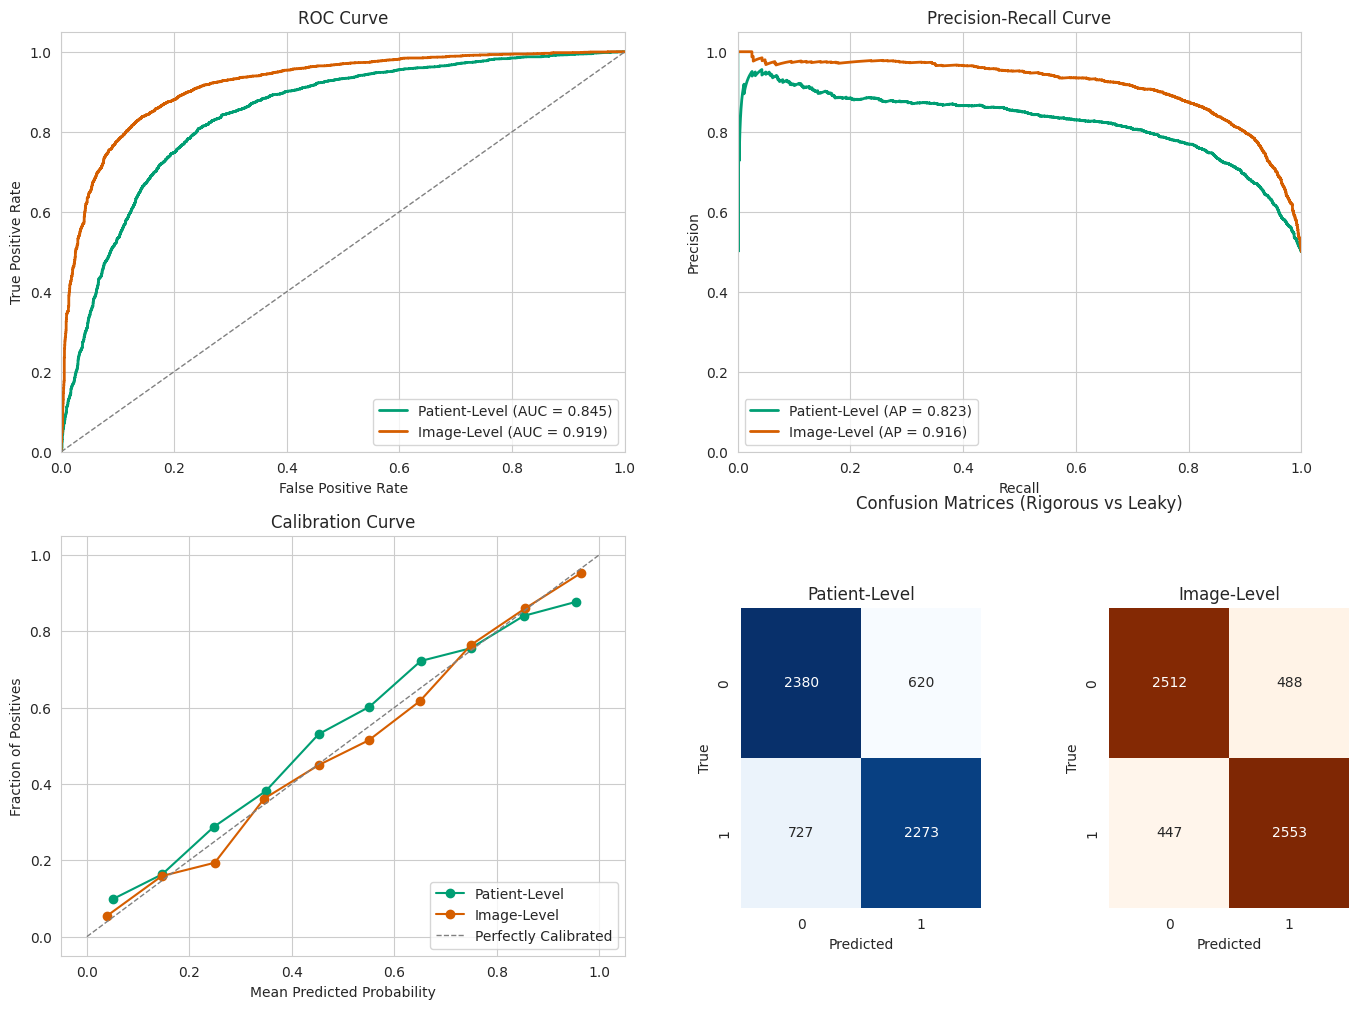

Metrics and 4-panel figure saved to: /kaggle/working/q1


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (roc_curve, auc, confusion_matrix, precision_score, 
                             recall_score, brier_score_loss, log_loss, matthews_corrcoef, 
                             cohen_kappa_score, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

# 1. Aggregate predictions across all folds
yt_all = np.concatenate([fold['yt'] for fold in PR])
ypr_patient = np.concatenate([fold['ypr'] for fold in PR])
ypr_random = np.concatenate([fold['ypr'] for fold in RR])
yp_patient = np.concatenate([fold['yp'] for fold in PR])
yp_random = np.concatenate([fold['yp'] for fold in RR])

# 2. Comprehensive Metrics Calculation
def calc_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'AUC': auc(*roc_curve(y_true, y_prob)[:2]),
        'PR-AUC (Average Precision)': average_precision_score(y_true, y_prob),
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'F1 Score': 2*tp / (2*tp + fp + fn),
        'Precision (PPV)': tp / (tp + fp) if (tp+fp)>0 else 0,
        'Recall / Sensitivity (TPR)': tp / (tp + fn) if (tp+fn)>0 else 0,
        'Specificity (TNR)': tn / (tn + fp) if (tn+fp)>0 else 0,
        'Brier Score (lower is better)': brier_score_loss(y_true, y_prob),
        'Log Loss (lower is better)': log_loss(y_true, y_prob),
        'Matthews Corr. Coef. (MCC)': matthews_corrcoef(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred)
    }

df_metrics = pd.DataFrame({
    'Patient-Level (Rigorous)': calc_metrics(yt_all, yp_patient, ypr_patient),
    'Image-Level (Leaky)': calc_metrics(yt_all, yp_random, ypr_random)
})
df_metrics['Delta (Leaky - Rigorous)'] = df_metrics['Image-Level (Leaky)'] - df_metrics['Patient-Level (Rigorous)']
print("\n=== EXHAUSTIVE METRICS ===")
print(df_metrics.round(4))
df_metrics.to_csv(OUT / 'exhaustive_metrics.csv')

# 3. Setup 2x2 Figure Grid for Visuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# Plot A: ROC Curve
fpr_pat, tpr_pat, _ = roc_curve(yt_all, ypr_patient)
fpr_ran, tpr_ran, _ = roc_curve(yt_all, ypr_random)
axes[0,0].plot(fpr_pat, tpr_pat, color='#009E73', lw=2, label=f'Patient-Level (AUC = {df_metrics.loc["AUC", "Patient-Level (Rigorous)"]:.3f})')
axes[0,0].plot(fpr_ran, tpr_ran, color='#D55E00', lw=2, label=f'Image-Level (AUC = {df_metrics.loc["AUC", "Image-Level (Leaky)"]:.3f})')
axes[0,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0,0].set(xlim=[0, 1], ylim=[0, 1.05], xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[0,0].legend(loc="lower right")

# Plot B: Precision-Recall Curve
pre_pat, rec_pat, _ = precision_recall_curve(yt_all, ypr_patient)
pre_ran, rec_ran, _ = precision_recall_curve(yt_all, ypr_random)
axes[0,1].plot(rec_pat, pre_pat, color='#009E73', lw=2, label=f'Patient-Level (AP = {df_metrics.loc["PR-AUC (Average Precision)", "Patient-Level (Rigorous)"]:.3f})')
axes[0,1].plot(rec_ran, pre_ran, color='#D55E00', lw=2, label=f'Image-Level (AP = {df_metrics.loc["PR-AUC (Average Precision)", "Image-Level (Leaky)"]:.3f})')
axes[0,1].set(xlim=[0, 1], ylim=[0, 1.05], xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[0,1].legend(loc="lower left")

# Plot C: Calibration Curve (Reliability)
prob_true_pat, prob_pred_pat = calibration_curve(yt_all, ypr_patient, n_bins=10)
prob_true_ran, prob_pred_ran = calibration_curve(yt_all, ypr_random, n_bins=10)
axes[1,0].plot(prob_pred_pat, prob_true_pat, marker='o', color='#009E73', label='Patient-Level')
axes[1,0].plot(prob_pred_ran, prob_true_ran, marker='o', color='#D55E00', label='Image-Level')
axes[1,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Perfectly Calibrated')
axes[1,0].set(xlabel='Mean Predicted Probability', ylabel='Fraction of Positives', title='Calibration Curve')
axes[1,0].legend(loc="lower right")

# Plot D: Side-by-Side Confusion Matrices (Inset style)
cm_pat = confusion_matrix(yt_all, yp_patient)
cm_ran = confusion_matrix(yt_all, yp_random)
ax_cm1 = fig.add_axes([0.55, 0.15, 0.15, 0.25]) # Custom positioning for the first CM
ax_cm2 = fig.add_axes([0.78, 0.15, 0.15, 0.25]) # Custom positioning for the second CM
axes[1,1].axis('off') # Hide the default axes
axes[1,1].set_title('Confusion Matrices (Rigorous vs Leaky)', pad=20)

sns.heatmap(cm_pat, annot=True, fmt='d', cmap='Blues', ax=ax_cm1, cbar=False)
ax_cm1.set(title='Patient-Level', xlabel='Predicted', ylabel='True')
sns.heatmap(cm_ran, annot=True, fmt='d', cmap='Oranges', ax=ax_cm2, cbar=False)
ax_cm2.set(title='Image-Level', xlabel='Predicted', ylabel='True')

plt.savefig(OUT / 'comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Metrics and 4-panel figure saved to: {OUT}")


## 🔬 CMPB Add-ons — Matched XAI · ConvNeXt · Leakage Severity · Natural Imbalance
Run Add-on 0 (shared helpers) first. Each add-on is independently checkpoint-resumable.

In [19]:
# ====== CMPB ADD-ON SHARED HELPERS ======
import numpy as np, pandas as pd, torch, torch.nn as nn, time
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt, seaborn as sns

# Park previously-trained patient models on CPU to free GPU during add-on training
for _r in PR:
    if isinstance(_r, dict) and 'model' in _r:
        try: _r['model'].to('cpu')
        except Exception: pass
torch.cuda.empty_cache()

def mkmodel_convnext():
    m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, 2)
    m = m.to(DEVICE)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m

def train_arch(tr, te, fold, name, model_fn, epochs=EPOCHS, class_weight=None,
               keep_model=True, verbose=True):
    # Architecture-agnostic training mirroring train(): AUC early-stopping + cosine LR
    print(f"   >> training {name} F{fold} (tr={len(tr)} te={len(te)}) ...", flush=True)
    trL = dl(tr, aug=True); teL = dl(te, aug=False, sh=False)
    m = model_fn(); opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    fn = nn.CrossEntropyLoss(weight=class_weight)
    best = 0.0; bst = None; cnt = 0
    for ep in range(epochs):
        _ep_t = time.time()
        m.train()
        for x, y, _ in trL:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); fn(m(x), y).backward(); opt.step()
        sch.step()
        _, vauc, _, _, _, _, _ = evl(m, teL)
        print(f"      {name} F{fold} epoch {ep+1}/{epochs}  valAUC={vauc:.4f}  ({time.time()-_ep_t:.0f}s)", flush=True)
        if vauc > best:
            best = vauc; bst = {k: v.clone() for k, v in m.state_dict().items()}; cnt = 0
        else:
            cnt += 1
            if cnt >= PATIENCE:
                print(f"      {name} F{fold} early-stop at epoch {ep+1}", flush=True)
                break
    m.load_state_dict(bst)
    _, auc, acc, f1, yt, yp, ypr = evl(m, teL)
    out = dict(name=name, fold=fold, auc=auc, acc=acc, f1=f1, yt=yt, yp=yp, ypr=ypr)
    if keep_model:
        out['model'] = m
    else:
        del m; torch.cuda.empty_cache()
    if verbose:
        print(f'   [{name} F{fold}] AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f}')
    return out

def ci95(v):
    v = np.array(v, dtype=float); m = v.mean()
    c = 1.96 * v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return m, c

def border_ratio(cam, frac=0.20):
    # Fraction of Grad-CAM activation mass in the outer border frame (shortcut proxy)
    h, w = cam.shape; bh = max(int(h*frac), 1); bw = max(int(w*frac), 1)
    mask = np.ones_like(cam, dtype=bool); mask[bh:h-bh, bw:w-bw] = False
    tot = float(cam.sum()) + 1e-8
    return float(cam[mask].sum()) / tot

def make_lime_pred(model):
    norm = T.Normalize(MN, ST)
    def _p(imgs):
        model.eval()
        ts = torch.stack([norm(torch.from_numpy(im.transpose(2,0,1)).float()) for im in imgs]).to(DEVICE)
        with torch.no_grad():
            return torch.softmax(model(ts), 1).cpu().numpy()
    return _p

print('CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred')

CMPB helpers ready: train_arch, mkmodel_convnext, ci95, border_ratio, make_lime_pred


Training matched leaky model for XAI...
   >> training Leaky-XAI F5 (tr=4800 te=1200) ...
      Leaky-XAI F5 epoch 1/12  valAUC=0.8325  (62s)
      Leaky-XAI F5 epoch 2/12  valAUC=0.8382  (60s)
      Leaky-XAI F5 epoch 3/12  valAUC=0.8645  (60s)
      Leaky-XAI F5 epoch 4/12  valAUC=0.8580  (60s)
      Leaky-XAI F5 epoch 5/12  valAUC=0.8563  (60s)
      Leaky-XAI F5 epoch 6/12  valAUC=0.8604  (60s)
      Leaky-XAI F5 early-stop at epoch 6
   [Leaky-XAI F5] AUC=0.8645 ACC=0.7908 F1=0.7958
  saved checkpoint: addon1_leaky


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

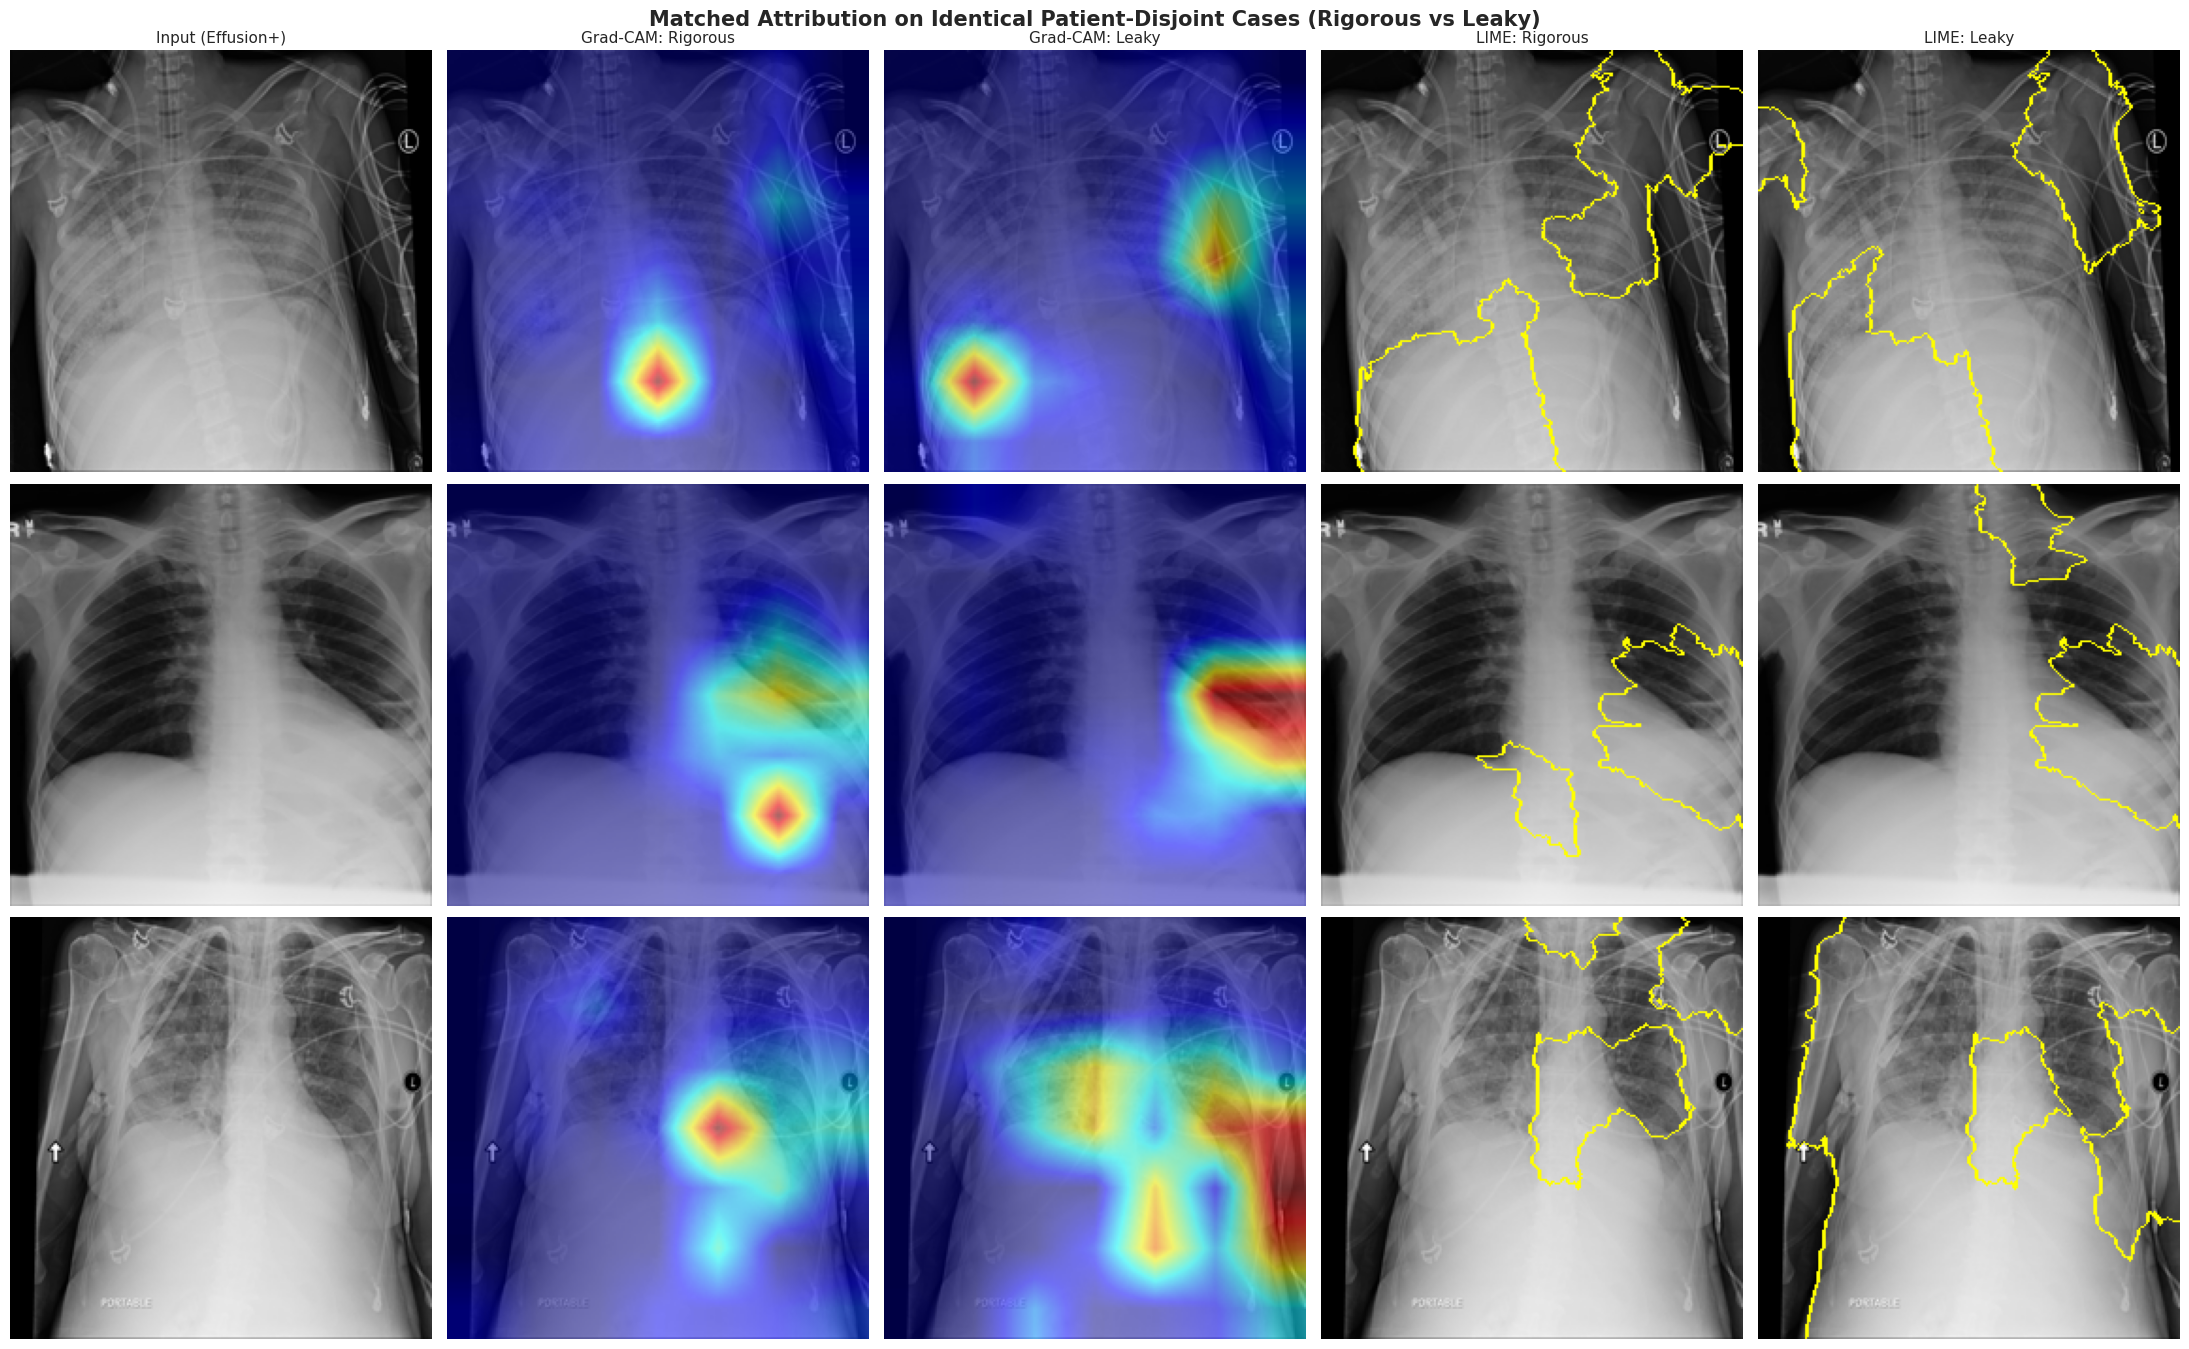


=== Peripheral (border) Grad-CAM mass: higher = more shortcut-like attention ===
  Rigorous model : 0.488
  Leaky model    : 0.608
  Delta (Leaky - Rigorous): +0.120
Add-on 1 complete -> addon1_matched_xai.png, addon1_border_ratio.csv


In [20]:
# ====== ADD-ON 1: MATCHED XAI (LEAKY vs RIGOROUS) ======
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# Rigorous model = last patient-split fold (already trained); bring back to GPU
rig_m = PR[-1]['model'].to(DEVICE); rig_m.eval()

# Train (or resume) a MATCHED leaky (random-split) model on the last random fold
_ti, _ei = rkf[-1]
_trR = nih.iloc[_ti].reset_index(drop=True)
_teR = nih.iloc[_ei].reset_index(drop=True)
leaky_m = load_model_ckpt(mkmodel, 'addon1_leaky')
if leaky_m is None:
    print('Training matched leaky model for XAI...')
    leaky_res = train_arch(_trR, _teR, FOLDS, 'Leaky-XAI', mkmodel, keep_model=True)
    leaky_m = leaky_res['model']; save_model_ckpt(leaky_m, 'addon1_leaky')
    print('  saved checkpoint: addon1_leaky')
else:
    print('Loaded matched leaky XAI model from checkpoint')
leaky_m.eval()

# Same held-out positive (Effusion) cases from the PATIENT test fold (unseen by rigorous model)
last_te = nih.iloc[gkf[-1][1]].reset_index(drop=True)
pos_pool = last_te[last_te.Label == 1]
n_show = min(3, len(pos_pool))
xai_df = pos_pool.sample(n_show, random_state=42).reset_index(drop=True)

base_r = rig_m.module if isinstance(rig_m, nn.DataParallel) else rig_m
base_l = leaky_m.module if isinstance(leaky_m, nn.DataParallel) else leaky_m
cam_r = GradCAM(model=rig_m, target_layers=[base_r.layer4[-1]])
cam_l = GradCAM(model=leaky_m, target_layers=[base_l.layer4[-1]])
lime_e = lime_image.LimeImageExplainer()
pred_r = make_lime_pred(rig_m); pred_l = make_lime_pred(leaky_m)

fig, axes = plt.subplots(n_show, 5, figsize=(22, 4.6*n_show))
if n_show == 1: axes = axes.reshape(1, -1)
cols = ['Input (Effusion+)', 'Grad-CAM: Rigorous', 'Grad-CAM: Leaky', 'LIME: Rigorous', 'LIME: Leaky']
fig.suptitle('Matched Attribution on Identical Patient-Disjoint Cases (Rigorous vs Leaky)', fontsize=15, fontweight='bold')
rig_bord, leaky_bord = [], []
for i, (_, row) in enumerate(xai_df.iterrows()):
    img = Image.open(row.filepath).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    inp = np.array(img).astype(np.float32) / 255.0
    t = BT(img).unsqueeze(0).to(DEVICE)
    gcr = cam_r(input_tensor=t, targets=[ClassifierOutputTarget(1)])[0]
    gcl = cam_l(input_tensor=t, targets=[ClassifierOutputTarget(1)])[0]
    rig_bord.append(border_ratio(gcr)); leaky_bord.append(border_ratio(gcl))
    er = lime_e.explain_instance(inp.astype('double'), pred_r, top_labels=1, hide_color=0, num_samples=300)
    tr_, mr_ = er.get_image_and_mask(er.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    el = lime_e.explain_instance(inp.astype('double'), pred_l, top_labels=1, hide_color=0, num_samples=300)
    tl_, ml_ = el.get_image_and_mask(el.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    panels = [inp, show_cam_on_image(inp, gcr, use_rgb=True), show_cam_on_image(inp, gcl, use_rgb=True),
              mark_boundaries(tr_, mr_), mark_boundaries(tl_, ml_)]
    for j, pan in enumerate(panels):
        axes[i, j].imshow(pan); axes[i, j].axis('off')
        if i == 0: axes[i, j].set_title(cols[j], fontsize=11)
plt.tight_layout(); plt.savefig(OUT/'addon1_matched_xai.png', dpi=300, bbox_inches='tight'); plt.show()

print('\n=== Peripheral (border) Grad-CAM mass: higher = more shortcut-like attention ===')
print(f'  Rigorous model : {np.mean(rig_bord):.3f}')
print(f'  Leaky model    : {np.mean(leaky_bord):.3f}')
print(f'  Delta (Leaky - Rigorous): {np.mean(leaky_bord)-np.mean(rig_bord):+.3f}')
pd.DataFrame({'sample': range(1, n_show+1), 'border_rigorous': rig_bord, 'border_leaky': leaky_bord}).to_csv(OUT/'addon1_border_ratio.csv', index=False)

rig_m.to('cpu'); del leaky_m
if 'leaky_res' in globals(): del leaky_res
torch.cuda.empty_cache()
print('Add-on 1 complete -> addon1_matched_xai.png, addon1_border_ratio.csv')

   >> training ConvNeXt-Patient F1 (tr=4800 te=1200) ...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 180MB/s]


      ConvNeXt-Patient F1 epoch 1/12  valAUC=0.8730  (102s)
      ConvNeXt-Patient F1 epoch 2/12  valAUC=0.8790  (96s)
      ConvNeXt-Patient F1 epoch 3/12  valAUC=0.8821  (96s)
      ConvNeXt-Patient F1 epoch 4/12  valAUC=0.8810  (96s)
      ConvNeXt-Patient F1 epoch 5/12  valAUC=0.8804  (96s)
      ConvNeXt-Patient F1 epoch 6/12  valAUC=0.8737  (96s)
      ConvNeXt-Patient F1 early-stop at epoch 6
   [ConvNeXt-Patient F1] AUC=0.8821 ACC=0.7567 F1=0.7165
   >> training ConvNeXt-Leaky F1 (tr=4800 te=1200) ...
      ConvNeXt-Leaky F1 epoch 1/12  valAUC=0.8587  (96s)
      ConvNeXt-Leaky F1 epoch 2/12  valAUC=0.8641  (95s)
      ConvNeXt-Leaky F1 epoch 3/12  valAUC=0.8681  (96s)
      ConvNeXt-Leaky F1 epoch 4/12  valAUC=0.8683  (95s)
      ConvNeXt-Leaky F1 epoch 5/12  valAUC=0.8737  (96s)
      ConvNeXt-Leaky F1 epoch 6/12  valAUC=0.8705  (96s)
      ConvNeXt-Leaky F1 epoch 7/12  valAUC=0.8491  (96s)
      ConvNeXt-Leaky F1 epoch 8/12  valAUC=0.8604  (96s)
      ConvNeXt-Leaky F1 early

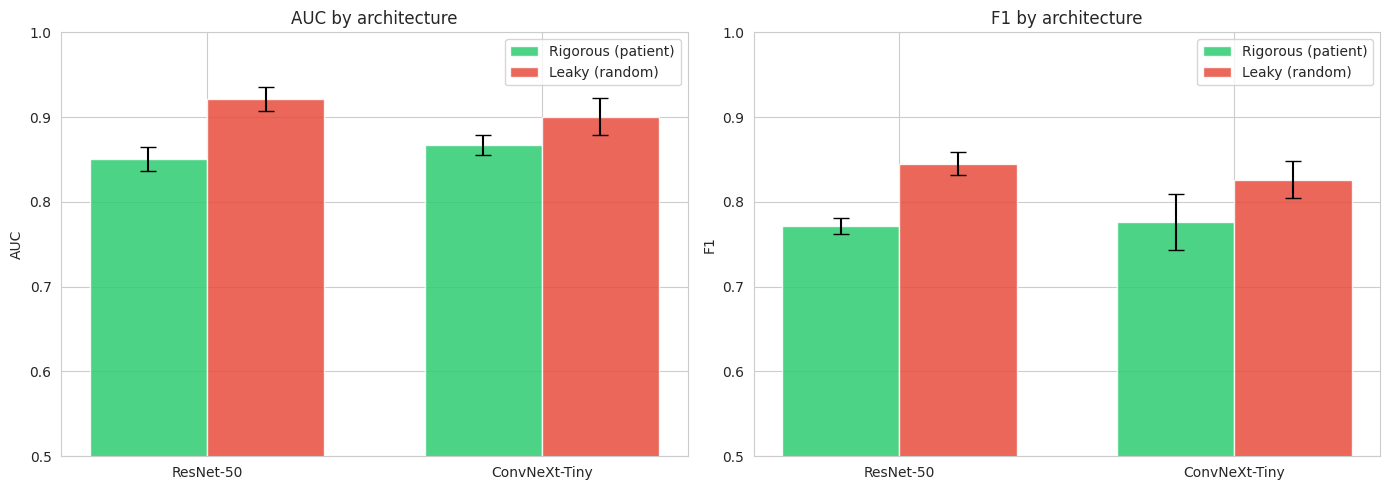

Add-on 2 complete -> addon2_architecture_comparison.{csv,png}


In [21]:
# ====== ADD-ON 2: CONVNEXT-TINY - FULL TWO-ARM PROTOCOL (resumable) ======
CN_PR, CN_RR = [], []
cn_yt, cn_pat, cn_ran = [], [], []
_t0 = time.time()
for f in range(FOLDS):
    if has_ckpt(f'addon2_fold{f+1}'):
        _c = load_pkl_ckpt(f'addon2_fold{f+1}')
        CN_PR.append(_c['rp']); CN_RR.append(_c['rr'])
        cn_yt.extend(_c['rp']['yt']); cn_pat.extend(_c['rp']['yp']); cn_ran.extend(_c['rr']['yp'])
        print(f'  \u23ed  ConvNeXt fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti, ei = gkf[f]
    trG = nih.iloc[ti].reset_index(drop=True); teG = nih.iloc[ei].reset_index(drop=True)
    if teG.Label.nunique() < 2:
        print(f'Fold {f+1}: single-class test, skipped'); continue
    rp = train_arch(trG, teG, f+1, 'ConvNeXt-Patient', mkmodel_convnext, keep_model=False)
    CN_PR.append(rp)
    ti2, ei2 = rkf[f]
    trR = nih.iloc[ti2].reset_index(drop=True); teR = nih.iloc[ei2].reset_index(drop=True)
    lm = train_arch(trR, teR, f+1, 'ConvNeXt-Leaky', mkmodel_convnext, keep_model=True, verbose=False)
    _, af, ac, f1f, ytf, ypf, yprf = evl(lm['model'], dl(teG, aug=False, sh=False))
    rr = dict(auc=af, acc=ac, f1=f1f, yt=ytf, yp=ypf, ypr=yprf)
    CN_RR.append(rr)
    del lm['model'], lm; torch.cuda.empty_cache()
    cn_yt.extend(rp['yt']); cn_pat.extend(rp['yp']); cn_ran.extend(ypf)
    save_pkl_ckpt({'rp': rp, 'rr': rr}, f'addon2_fold{f+1}')
    print(f'  Fold {f+1}: Patient AUC={rp["auc"]:.4f} | Leaky@PatientTest AUC={af:.4f}  (delta={af-rp["auc"]:+.4f})  [checkpoint saved]')
print(f'ConvNeXt two-arm protocol done in {(time.time()-_t0)/60:.1f} min')

def _agg(res_list, met): return ci95([r[met] for r in res_list])
rows = []
for met in ['auc', 'acc', 'f1']:
    for arch, prl, rrl in [('ResNet-50', PR, RR), ('ConvNeXt-Tiny', CN_PR, CN_RR)]:
        pm, pc = _agg(prl, met); rm, rc = _agg(rrl, met)
        rows.append(dict(Architecture=arch, Metric=met.upper(),
                         Rigorous=f'{pm:.4f}+/-{pc:.4f}', Leaky=f'{rm:.4f}+/-{rc:.4f}', Inflation=f'{rm-pm:+.4f}'))
cn_tab = pd.DataFrame(rows)
print('\n=== CROSS-ARCHITECTURE LEAKAGE INFLATION (NIH) ===')
print(cn_tab.to_string(index=False))
cn_tab.to_csv(OUT/'addon2_architecture_comparison.csv', index=False)

from statsmodels.stats.contingency_tables import mcnemar
_yt = np.array(cn_yt); _pp = np.array(cn_pat); _rr = np.array(cn_ran)
_pc = (_pp == _yt); _rc = (_rr == _yt)
_tbl = [[int(np.sum(_pc & _rc)), int(np.sum(_pc & ~_rc))], [int(np.sum(~_pc & _rc)), int(np.sum(~_pc & ~_rc))]]
_mc = mcnemar(_tbl, exact=False, correction=True)
print(f'\nConvNeXt McNemar: chi2={_mc.statistic:.4f}  p={_mc.pvalue:.2e}  ->', 'SIGNIFICANT' if _mc.pvalue<0.05 else 'n.s.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
archs = ['ResNet-50', 'ConvNeXt-Tiny']; x = np.arange(len(archs)); w = 0.35
for k, met in enumerate(['auc', 'f1']):
    pr_m = [ci95([r[met] for r in PR])[0], ci95([r[met] for r in CN_PR])[0]]
    pr_c = [ci95([r[met] for r in PR])[1], ci95([r[met] for r in CN_PR])[1]]
    rr_m = [ci95([r[met] for r in RR])[0], ci95([r[met] for r in CN_RR])[0]]
    rr_c = [ci95([r[met] for r in RR])[1], ci95([r[met] for r in CN_RR])[1]]
    ax = axes[k]
    ax.bar(x-w/2, pr_m, w, yerr=pr_c, capsize=6, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
    ax.bar(x+w/2, rr_m, w, yerr=rr_c, capsize=6, label='Leaky (random)', color='#e74c3c', alpha=0.85)
    ax.set(xticks=x, xticklabels=archs, ylabel=met.upper(), title=f'{met.upper()} by architecture', ylim=[0.5, 1.0]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon2_architecture_comparison.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 2 complete -> addon2_architecture_comparison.{csv,png}')

   >> training Leaky-Severity F1 (tr=4800 te=1200) ...
      Leaky-Severity F1 epoch 1/12  valAUC=0.8351  (60s)
      Leaky-Severity F1 epoch 2/12  valAUC=0.8504  (60s)
      Leaky-Severity F1 epoch 3/12  valAUC=0.8514  (60s)
      Leaky-Severity F1 epoch 4/12  valAUC=0.8573  (60s)
      Leaky-Severity F1 epoch 5/12  valAUC=0.8563  (60s)
      Leaky-Severity F1 epoch 6/12  valAUC=0.8563  (60s)
      Leaky-Severity F1 epoch 7/12  valAUC=0.8387  (60s)
      Leaky-Severity F1 early-stop at epoch 7
   [Leaky-Severity F1] AUC=0.8573 ACC=0.7725 F1=0.7628
  Fold 1: 1200 test images scored [checkpoint saved]
   >> training Leaky-Severity F2 (tr=4800 te=1200) ...
      Leaky-Severity F2 epoch 1/12  valAUC=0.8093  (60s)
      Leaky-Severity F2 epoch 2/12  valAUC=0.8410  (60s)
      Leaky-Severity F2 epoch 3/12  valAUC=0.8388  (60s)
      Leaky-Severity F2 epoch 4/12  valAUC=0.8473  (60s)
      Leaky-Severity F2 epoch 5/12  valAUC=0.8413  (60s)
      Leaky-Severity F2 epoch 6/12  valAUC=0.8447  (

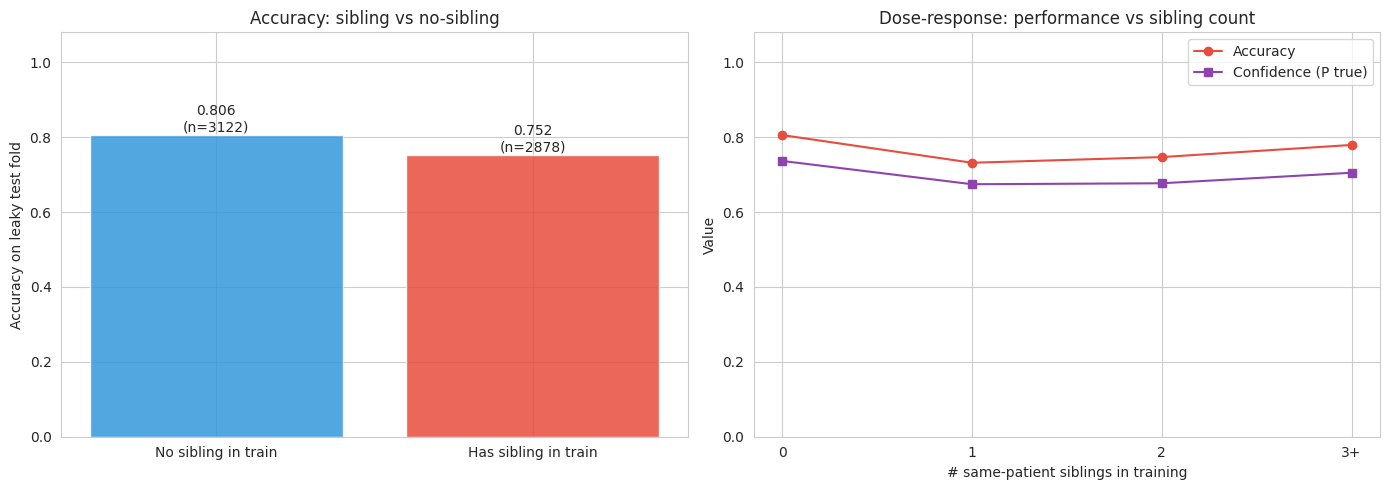

Add-on 3 complete -> addon3_leakage_severity.{csv,png}


In [22]:
# ====== ADD-ON 3: LEAKAGE SEVERITY ANALYSIS (dose-response, resumable) ======
from scipy.stats import spearmanr
sev_records = []
for f in range(FOLDS):
    if has_ckpt(f'addon3_fold{f+1}'):
        sev_records.extend(load_pkl_ckpt(f'addon3_fold{f+1}'))
        print(f'  \u23ed  Severity fold {f+1} loaded from checkpoint (skipped retraining)')
        continue
    ti2, ei2 = rkf[f]
    trR = nih.iloc[ti2].reset_index(drop=True)
    teR = nih.iloc[ei2].reset_index(drop=True)
    if teR.Label.nunique() < 2:
        continue
    lm = train_arch(trR, teR, f+1, 'Leaky-Severity', mkmodel, keep_model=True, verbose=True)
    _, _, _, _, yt, yp, ypr = evl(lm['model'], dl(teR, aug=False, sh=False))
    tc = trR.Patient_ID.value_counts()
    nsib = teR.Patient_ID.map(tc).fillna(0).astype(int).values
    labels = teR.Label.values.astype(int)
    prob_true = np.where(labels == 1, ypr, 1 - ypr)
    correct = (yp == labels).astype(int)
    fold_records = []
    for k in range(len(teR)):
        fold_records.append(dict(fold=f+1, label=int(labels[k]), n_train_siblings=int(nsib[k]),
                                 has_sibling=int(nsib[k] > 0), correct=int(correct[k]),
                                 prob_true=float(prob_true[k])))
    sev_records.extend(fold_records)
    save_pkl_ckpt(fold_records, f'addon3_fold{f+1}')
    print(f'  Fold {f+1}: {len(fold_records)} test images scored [checkpoint saved]')
    del lm['model'], lm; torch.cuda.empty_cache()

sev_df = pd.DataFrame(sev_records)
sev_df.to_csv(OUT/'addon3_leakage_severity.csv', index=False)

grp = sev_df.groupby('has_sibling').agg(n=('correct', 'size'), accuracy=('correct', 'mean'),
                                        mean_confidence=('prob_true', 'mean')).reset_index()
grp['group'] = grp['has_sibling'].map({0: 'No sibling in train', 1: 'Has sibling in train'})
print('\n=== LEAKAGE SEVERITY: siblinged vs non-siblinged test images ===')
print(grp[['group', 'n', 'accuracy', 'mean_confidence']].to_string(index=False))

rho_c, p_c = spearmanr(sev_df.n_train_siblings, sev_df.correct)
rho_p, p_p = spearmanr(sev_df.n_train_siblings, sev_df.prob_true)
print(f'\nSpearman  n_siblings vs correctness : rho={rho_c:+.3f}  p={p_c:.2e}')
print(f'Spearman  n_siblings vs confidence  : rho={rho_p:+.3f}  p={p_p:.2e}')

def _bucket(n):
    return '0' if n == 0 else ('1' if n == 1 else ('2' if n == 2 else '3+'))
sev_df['sib_bucket'] = sev_df.n_train_siblings.map(_bucket)
order = ['0', '1', '2', '3+']
buck = sev_df.groupby('sib_bucket').agg(accuracy=('correct', 'mean'), confidence=('prob_true', 'mean'),
                                        n=('correct', 'size')).reindex(order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); sns.set_style('whitegrid')
ax = axes[0]
ax.bar(grp['group'], grp['accuracy'], color=['#3498db', '#e74c3c'], alpha=0.85)
for i, v in enumerate(grp['accuracy']):
    ax.text(i, v+0.01, f'{v:.3f}\n(n={int(grp.n.iloc[i])})', ha='center')
ax.set(ylabel='Accuracy on leaky test fold', title='Accuracy: sibling vs no-sibling', ylim=[0, 1.08])
ax = axes[1]
ax.plot(buck.index, buck['accuracy'], marker='o', color='#e74c3c', label='Accuracy')
ax.plot(buck.index, buck['confidence'], marker='s', color='#8e44ad', label='Confidence (P true)')
ax.set(xlabel='# same-patient siblings in training', ylabel='Value',
       title='Dose-response: performance vs sibling count', ylim=[0, 1.08]); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon3_leakage_severity.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 3 complete -> addon3_leakage_severity.{csv,png}')

Imbalanced pool: 3333 images | 2799 patients | prevalence=0.100 (333 positive)

Training RIGOROUS (patient-disjoint) arm...
   >> training NatImb-Patient F1 (tr=2675 te=658) ...
      NatImb-Patient F1 epoch 1/12  valAUC=0.7777  (33s)
      NatImb-Patient F1 epoch 2/12  valAUC=0.8362  (33s)
      NatImb-Patient F1 epoch 3/12  valAUC=0.8408  (33s)
      NatImb-Patient F1 epoch 4/12  valAUC=0.8273  (34s)
      NatImb-Patient F1 epoch 5/12  valAUC=0.8450  (34s)
      NatImb-Patient F1 epoch 6/12  valAUC=0.8302  (34s)
      NatImb-Patient F1 epoch 7/12  valAUC=0.8528  (34s)
      NatImb-Patient F1 epoch 8/12  valAUC=0.8492  (34s)
      NatImb-Patient F1 epoch 9/12  valAUC=0.8489  (34s)
      NatImb-Patient F1 epoch 10/12  valAUC=0.8419  (34s)
      NatImb-Patient F1 early-stop at epoch 10
   [NatImb-Patient F1] AUC=0.8528 ACC=0.8116 F1=0.3922
  saved checkpoint: addon4_rigorous
Training LEAKY (random-split) arm...
   >> training NatImb-Leaky F1 (tr=2666 te=658) ...
      NatImb-Leaky F1 ep

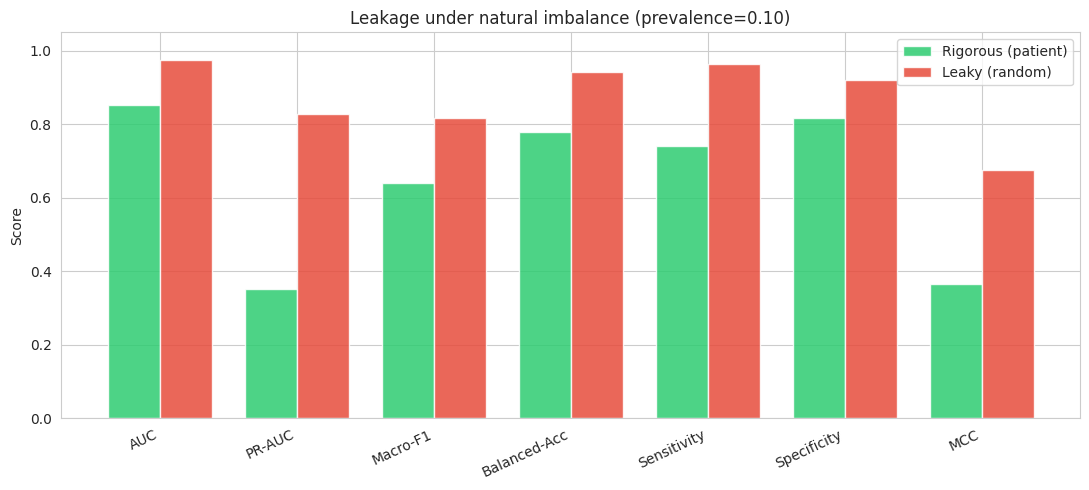

Add-on 4 complete -> addon4_natural_imbalance.{csv,png}


In [23]:
# ====== ADD-ON 4: NATURAL CLASS-IMBALANCE SETTING (resumable) ======
# Approximate deployment imbalance: fix benign at MAX_BENIGN and subsample Effusion
# positives to hit a LOW target prevalence (NIH Effusion is abundant, so unlike ISIC
# we must down-sample positives). Both arms use identical class-weighted training;
# only the SPLIT differs (patient-disjoint vs random). The leaky arm's random 80% may
# pull same-patient siblings of test patients into training (the leakage under study).
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, recall_score)

NAT_PREV = 0.10        # target positive (Effusion) prevalence
MAX_BENIGN = 3000      # benign cap for notebook tractability

_full = pd.read_csv(CSV); _full.columns = _full.columns.str.strip()
_full['Label'] = _full['Finding Labels'].apply(lambda x: 1 if TARGET in str(x) else 0)
_full['Patient_ID'] = _full['Patient ID'].astype(str).str.strip()
_full['filepath'] = _full['Image Index'].map(IDX)
_full = _full.dropna(subset=['filepath']).reset_index(drop=True)
_pos = _full[_full.Label == 1]; _neg = _full[_full.Label == 0]
_nb = min(len(_neg), MAX_BENIGN)
_npos = min(len(_pos), int(round(_nb * NAT_PREV / (1 - NAT_PREV))))
nat = pd.concat([_pos.sample(_npos, random_state=SEED),
                 _neg.sample(_nb, random_state=SEED)]).sample(frac=1, random_state=SEED).reset_index(drop=True)
prev = nat.Label.mean()
print(f'Imbalanced pool: {len(nat)} images | {nat.Patient_ID.nunique()} patients | prevalence={prev:.3f} ({int(nat.Label.sum())} positive)')

# Patient-disjoint test fold (shared by BOTH arms)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
_tr, _te = next(gss.split(nat, nat.Label, groups=nat.Patient_ID))
natG_tr = nat.iloc[_tr].reset_index(drop=True); natG_te = nat.iloc[_te].reset_index(drop=True)
# Leaky arm: random 80% of the whole pool
_rng = np.random.RandomState(SEED); _perm = _rng.permutation(len(nat)); _cut = int(0.8*len(nat))
natR_tr = nat.iloc[_perm[:_cut]].reset_index(drop=True)

def _cw(df):
    n = len(df); c = df.Label.value_counts()
    return torch.tensor([n/(2*max(int(c.get(0, 1)), 1)), n/(2*max(int(c.get(1, 1)), 1))],
                        dtype=torch.float32, device=DEVICE)

_rg = load_pkl_ckpt('addon4_rigorous')
if _rg is None:
    print('\nTraining RIGOROUS (patient-disjoint) arm...')
    nat_rig = train_arch(natG_tr, natG_te, 1, 'NatImb-Patient', mkmodel, class_weight=_cw(natG_tr), keep_model=True)
    _, _, _, _, ytg, ypg, yprg = evl(nat_rig['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytg, 'yp': ypg, 'ypr': yprg}, 'addon4_rigorous')
    del nat_rig['model'], nat_rig; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_rigorous')
else:
    ytg, ypg, yprg = _rg['yt'], _rg['yp'], _rg['ypr']; print('Loaded RIGOROUS arm from checkpoint')

_lk = load_pkl_ckpt('addon4_leaky')
if _lk is None:
    print('Training LEAKY (random-split) arm...')
    nat_lk = train_arch(natR_tr, natG_te, 1, 'NatImb-Leaky', mkmodel, class_weight=_cw(natR_tr), keep_model=True)
    _, _, _, _, ytl, ypl, yprl = evl(nat_lk['model'], dl(natG_te, aug=False, sh=False))
    save_pkl_ckpt({'yt': ytl, 'yp': ypl, 'ypr': yprl}, 'addon4_leaky')
    del nat_lk['model'], nat_lk; torch.cuda.empty_cache()
    print('  saved checkpoint: addon4_leaky')
else:
    ytl, ypl, yprl = _lk['yt'], _lk['yp'], _lk['ypr']; print('Loaded LEAKY arm from checkpoint')

def _imb_metrics(yt, yp, ypr):
    return {'AUC': roc_auc_score(yt, ypr), 'PR-AUC': average_precision_score(yt, ypr),
            'Macro-F1': f1_score(yt, yp, average='macro', zero_division=0),
            'Balanced-Acc': balanced_accuracy_score(yt, yp),
            'Sensitivity': recall_score(yt, yp, pos_label=1, zero_division=0),
            'Specificity': recall_score(yt, yp, pos_label=0, zero_division=0),
            'MCC': matthews_corrcoef(yt, yp)}
nat_tab = pd.DataFrame({'Rigorous (patient)': _imb_metrics(ytg, ypg, yprg),
                        'Leaky (random)': _imb_metrics(ytl, ypl, yprl)})
nat_tab['Inflation (Leaky-Rigorous)'] = nat_tab['Leaky (random)'] - nat_tab['Rigorous (patient)']
print(f'\n=== NATURAL-IMBALANCE RESULTS (prevalence={prev:.3f}) - same patient-disjoint test fold ===')
print(nat_tab.round(4).to_string())
nat_tab.to_csv(OUT/'addon4_natural_imbalance.csv')

fig, ax = plt.subplots(figsize=(11, 5)); sns.set_style('whitegrid')
mets = list(nat_tab.index); x = np.arange(len(mets)); w = 0.38
ax.bar(x-w/2, nat_tab['Rigorous (patient)'].values, w, label='Rigorous (patient)', color='#2ecc71', alpha=0.85)
ax.bar(x+w/2, nat_tab['Leaky (random)'].values, w, label='Leaky (random)', color='#e74c3c', alpha=0.85)
ax.set(xticks=x, xticklabels=mets, ylabel='Score', title=f'Leakage under natural imbalance (prevalence={prev:.2f})', ylim=[0, 1.05])
plt.setp(ax.get_xticklabels(), rotation=25, ha='right'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'addon4_natural_imbalance.png', dpi=300, bbox_inches='tight'); plt.show()
print('Add-on 4 complete -> addon4_natural_imbalance.{csv,png}')

In [24]:
# ====== FINAL BUNDLE: base results + all add-on outputs ======
import shutil, pickle, torch
print('Bundling all Q1 + CMPB add-on results...')
for i in range(len(PR)):
    if isinstance(PR[i], dict) and 'model' in PR[i]:
        try: torch.save(_sd(PR[i]['model']), OUT/f'patient_model_fold_{i+1}.pth')
        except Exception as e: print('  skip model', i+1, e)
hist = {'Patient-Split': [strip_model(r) for r in PR],
        'Random-Split':  [dict(r) for r in RR]}
with open(OUT/'training_evaluation_history.pkl', 'wb') as fh: pickle.dump(hist, fh)
zip_path = shutil.make_archive('/kaggle/working/NIH_Final_Q1_Results_WITH_ADDONS', 'zip', str(OUT))
print('DONE ->', zip_path)
from IPython.display import FileLink
FileLink(zip_path)

Bundling all Q1 + CMPB add-on results...
DONE -> /kaggle/working/NIH_Final_Q1_Results_WITH_ADDONS.zip


/kaggle/working/NIH_Final_Q1_Results_WITH_ADDONS.zip